{'A (path)': (250,), 'B (ring)': (250,), 'C (complete)': (250,)} central: (250,)


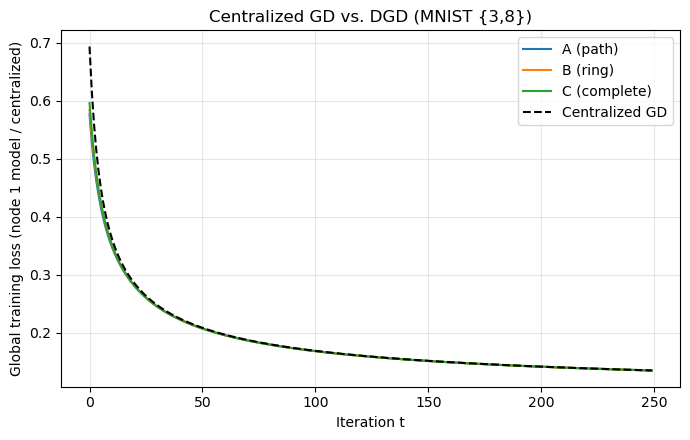

In [5]:
import os, struct, gzip, urllib.request
import numpy as np
import matplotlib.pyplot as plt

# --- tiny loader for MNIST raw .gz files (train only) ---
DATA_DIR = "./mnist"
os.makedirs(DATA_DIR, exist_ok=True)
URLS = {
    "images": "https://storage.googleapis.com/cvdf-datasets/mnist/train-images-idx3-ubyte.gz",
    "labels": "https://storage.googleapis.com/cvdf-datasets/mnist/train-labels-idx1-ubyte.gz",
}

def fetch(path, url):
    if not os.path.exists(path):
        print(f"downloading {url} -> {path}")
        urllib.request.urlretrieve(url, path)

def read_images_gz(path_gz):
    with gzip.open(path_gz, "rb") as f:
        magic, n, r, c = struct.unpack(">IIII", f.read(16))
        assert magic == 2051
        arr = np.frombuffer(f.read(), dtype=np.uint8).reshape(n, r*c)
        return (arr.astype(np.float32) / 255.0)

def read_labels_gz(path_gz):
    with gzip.open(path_gz, "rb") as f:
        magic, n = struct.unpack(">II", f.read(8))
        assert magic == 2049
        return np.frombuffer(f.read(), dtype=np.uint8).astype(np.int32)

def load_mnist_38(seed=1):
    img_gz = os.path.join(DATA_DIR, "train-images-idx3-ubyte.gz")
    lbl_gz = os.path.join(DATA_DIR, "train-labels-idx1-ubyte.gz")
    fetch(img_gz, URLS["images"]); fetch(lbl_gz, URLS["labels"])
    X = read_images_gz(img_gz)
    y = read_labels_gz(lbl_gz)
    m = (y==3) | (y==8)
    X = X[m].astype(np.float32)
    y = (y[m]==8).astype(np.int32)  # 8->1, 3->0
    rng = np.random.default_rng(seed)
    idx = rng.permutation(len(y))
    return X[idx], y[idx]

# --- utilities ---
def split_uniform(X, y, nodes=4, seed=1):
    rng = np.random.default_rng(seed)
    idx0, idx1 = np.where(y==0)[0], np.where(y==1)[0]
    rng.shuffle(idx0); rng.shuffle(idx1)
    parts = [[] for _ in range(nodes)]
    for k,i in enumerate(idx0): parts[k%nodes].append(i)
    for k,i in enumerate(idx1): parts[k%nodes].append(i)
    return [(X[np.array(p)], y[np.array(p)]) for p in parts]

def softplus(z):  # stable log(1+exp(z))
    return np.maximum(z,0) + np.log1p(np.exp(-np.abs(z)))

def loss_and_grad(theta, X, y, l2=0.0):
    # theta = [w; b], logistic loss: mean(softplus(z) - y*z)
    n, d = X.shape
    w, b = theta[:-1], theta[-1]
    z = X @ w + b
    L = np.mean(softplus(z) - y*z) + (l2/2.0)*float(np.dot(w,w))
    # grad: (sigmoid(z)-y)
    zc = np.clip(z, -40.0, 40.0)
    p = 1.0/(1.0+np.exp(-zc))
    diff = (p - y).astype(np.float32)
    gw = (X.T @ diff)/n + l2*w
    gb = float(np.mean(diff))
    g = np.concatenate([gw, np.array([gb], dtype=np.float32)])
    return np.float32(L), g

def laplacian(A):
    D = np.diag(np.sum(A, axis=1))
    return D - A

def central_gd(X, y, T=250, gamma=0.1, l2=0.0):
    d = X.shape[1]
    theta = np.zeros(d+1, dtype=np.float32)
    hist  = np.empty(T, dtype=np.float32)
    for t in range(T):
        L, g   = loss_and_grad(theta, X, y, l2=l2)
        theta -= gamma * g
        hist[t] = L
    return hist

# --- minimal DGD core ---
def dgd(node_splits, A, T=250, alpha=0.2, gamma=0.1, l2=0.0, seed=1):
    rng   = np.random.default_rng(seed)
    d     = node_splits[0][0].shape[1]
    nodes = len(node_splits)
    Theta = (0.05*rng.standard_normal((nodes, d+1))).astype(np.float32)
    Xall  = np.concatenate([Xi for Xi,_ in node_splits], axis=0).astype(np.float32)
    yall  = np.concatenate([yi for _,yi in node_splits], axis=0).astype(np.int32)
    Lmat  = laplacian(A).astype(np.float32)
    hist  = np.empty(T, dtype=np.float32)
    cons = np.empty(T, dtype=np.float32)
    for t in range(T):
        # gossip half-step
        Theta = Theta - alpha*(Lmat @ Theta)
        # local GD half-step
        for i,(Xi,yi) in enumerate(node_splits):
            _, g = loss_and_grad(Theta[i], Xi, yi, l2=l2)
            Theta[i] = Theta[i] - gamma*g
        # global loss at node 1's model
        hist[t], _ = loss_and_grad(Theta[0], Xall, yall, l2=0.0)

        theta_bar = Theta.mean(axis=0).astype(np.float32)
        cons[t] = 0.5 * np.sum(np.linalg.norm(Theta - theta_bar, axis=1)**2)
    return hist, cons

# --- three tiny graphs (path/ring/complete) ---
A_path = np.array([[0,1,0,0],[1,0,1,0],[0,1,0,1],[0,0,1,0]], dtype=np.float32)
A_ring = np.array([[0,1,0,1],[1,0,1,0],[0,1,0,1],[1,0,1,0]], dtype=np.float32)
A_K4   = np.ones((4,4), dtype=np.float32) - np.eye(4, dtype=np.float32)

# --- run (simple defaults) ---
X, y = load_mnist_38(seed=1)
splits = split_uniform(X, y, nodes=4, seed=1)

T = 250
ALPHA, GAMMA, L2 = 0.2, 0.1, 0.0

# 1) DGD per topology
lossA, _ = dgd(splits, A_path, T=T, alpha=ALPHA, gamma=GAMMA, l2=L2, seed=1)
lossB, _ = dgd(splits, A_ring, T=T, alpha=ALPHA, gamma=GAMMA, l2=L2, seed=1)
lossC, _ = dgd(splits, A_K4,   T=T, alpha=ALPHA, gamma=GAMMA, l2=L2, seed=1)

curves = {
    "A (path)": lossA,
    "B (ring)": lossB,
    "C (complete)": lossC,
}

# 2) Centralized GD baseline
Xall = np.concatenate([Xi for Xi,_ in splits], axis=0).astype(np.float32)
yall = np.concatenate([yi for _,yi in splits], axis=0).astype(np.int32)
central = central_gd(Xall, yall, T=T, gamma=GAMMA, l2=L2)

# 3) Sanity check (optional)
print({k: v.shape for k,v in curves.items()}, "central:", central.shape)

# 4) Plot (start a fresh figure, don’t plot inside loops)
import matplotlib.pyplot as plt
plt.close('all')
plt.figure(figsize=(7, 4.5))

for name, hist in curves.items():
    plt.plot(hist, label=name)

plt.plot(central, '--', color='k', label='Centralized GD')

plt.xlabel("Iteration t")
plt.ylabel("Global training loss (node 1 model / centralized)")
plt.title("Centralized GD vs. DGD (MNIST {3,8})")
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("q3_central_vs_dgd.png", dpi=200, bbox_inches="tight")
plt.show()

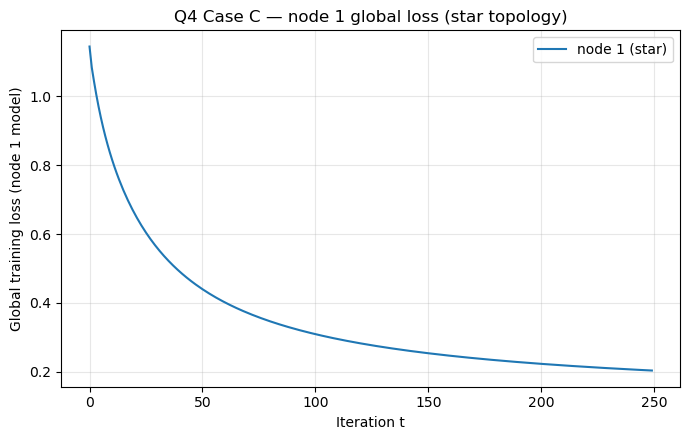

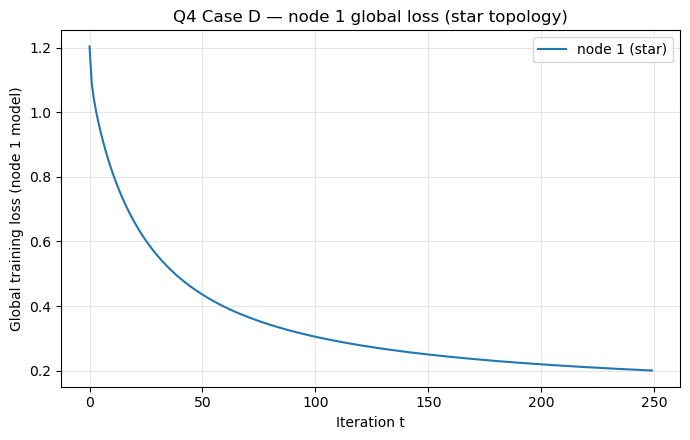

In [8]:
rng = np.random.default_rng(1)

def noniid_split_by_nodes(X, y, class_to_nodes, num_nodes=4, seed=1):
    """
    class_to_nodes: dict like {0:[1,3], 1:[2,4]} (1-indexed node ids)
    Uniformly scatter each class only across the listed nodes.
    """
    rng = np.random.default_rng(seed)
    parts = [[] for _ in range(num_nodes)]
    for c, nodes in class_to_nodes.items():
        idx = np.where(y == c)[0]
        rng.shuffle(idx)
        chunks = np.array_split(idx, len(nodes))
        for j, nid in enumerate(nodes):
            parts[nid-1].extend(chunks[j].tolist())
    splits = []
    for p in parts:
        p = np.array(p, dtype=int)
        splits.append((X[p].astype(np.float32), y[p].astype(np.int32)))
    return splits

# --- star topology used in Q4: edges {(1,4),(2,4),(3,4)}
A_star = np.array([[0,0,0,1],
                   [0,0,0,1],
                   [0,0,0,1],
                   [1,1,1,0]], dtype=np.float32)

# --- helper to run and plot the global training loss (node 1)
def run_and_plot_case(splits, A, title, T=250, alpha=0.2, gamma=0.1, save_as=None):
    hist, _ = dgd(splits, A, T=T, alpha=alpha, gamma=gamma, l2=0.0, seed=1)
    plt.figure(figsize=(7,4.5))
    plt.plot(hist, label="node 1 (star)")
    plt.xlabel("Iteration t")
    plt.ylabel("Global training loss (node 1 model)")
    plt.title(title)
    plt.grid(True, alpha=0.3); plt.legend(); plt.tight_layout()
    if save_as: plt.savefig(save_as, dpi=200, bbox_inches="tight")
    plt.show()
    return hist

# ---- Load data once
X, y = load_mnist_38(seed=1)  # 3->0, 8->1

# --------------------------- Q4, subpoint (1) ---------------------------
# Case C: all 3s -> nodes {1,3}; all 8s -> nodes {2,4}
caseC_map = {0: [1,3], 1: [2,4]}
splits_C = noniid_split_by_nodes(X, y, caseC_map, num_nodes=4, seed=1)

loss_C_star = run_and_plot_case(
    splits_C, A_star,
    title="Q4 Case C — node 1 global loss (star topology)",
    T=250, alpha=0.2, gamma=0.1, save_as="q4_caseC_star_node1_loss.png"
)

caseD_map = {1: [1,3], 0: [2,4]}


splits_D = noniid_split_by_nodes(X, y, caseD_map, num_nodes=4, seed=1)

loss_D_star = run_and_plot_case(
    splits_D, A_star,
    title="Q4 Case D — node 1 global loss (star topology)",
    T=250, alpha=0.2, gamma=0.1, save_as="q4_caseD_star_node1_loss.png"
)

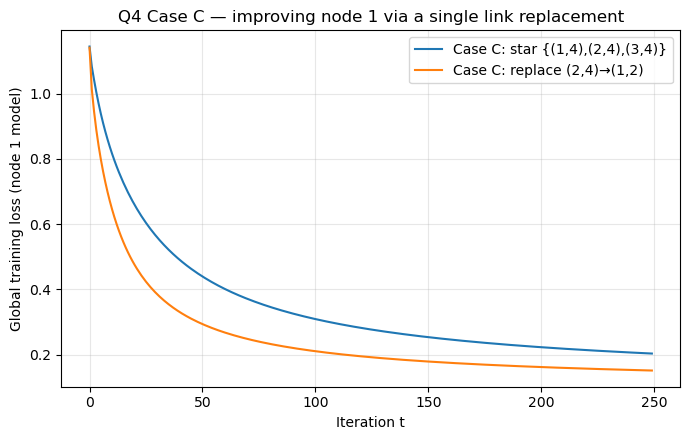

In [9]:
A_star_improved = A_star.copy()
A_star_improved[1,3] = A_star_improved[3,1] = 0
A_star_improved[0,1] = A_star_improved[1,0] = 1

T, ALPHA, GAMMA = 250, 0.2, 0.1
hist_star, _ = dgd(splits_C, A_star,           T=T, alpha=ALPHA, gamma=GAMMA, l2=0.0, seed=1)
hist_new,  _  = dgd(splits_C, A_star_improved, T=T, alpha=ALPHA, gamma=GAMMA, l2=0.0, seed=1)


plt.figure(figsize=(7,4.5))
plt.plot(hist_star, label="Case C: star {(1,4),(2,4),(3,4)}")
plt.plot(hist_new,  label="Case C: replace (2,4)→(1,2)")
plt.xlabel("Iteration t"); plt.ylabel("Global training loss (node 1 model)")
plt.title("Q4 Case C — improving node 1 via a single link replacement")
plt.grid(True, alpha=0.3); plt.legend(); plt.tight_layout()
plt.savefig("q4_caseC_topology_change.png", dpi=200, bbox_inches="tight")
plt.show()